# 1. Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    FunctionTransformer
)

from sklearn.model_selection import (
    train_test_split,
    cross_val_predict
)

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    average_precision_score
)

from imblearn.over_sampling import SMOTE

# 2. EDA

In [2]:
df = pd.read_csv(r'C:\Users\User\Downloads\archive\creditcard.csv')

In [3]:
df.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
df.nunique()

Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663
Amount     32767
Class          2
dtype: int64

In [7]:
df.isnull().sum(axis=0)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
fraud_duplicate = df[df["Class"] == 1].duplicated().sum()
print("Fraud duplicate:", fraud_duplicate)

Fraud duplicate: 19


In [10]:
non_fraud_duplicate = df[df["Class"] == 0].duplicated().sum()
print("Non Fraud duplicate:", non_fraud_duplicate)

Non Fraud duplicate: 1062


In [11]:
def analyze_fraud(df):

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # -----------------------------------
    # 1. Fraud vs Non-Fraud count
    # -----------------------------------
    sns.countplot(
        data=df,
        x="Class",
        ax=axes[0]
    )

    axes[0].set_title("Fraud vs Non-Fraud Transactions")
    axes[0].set_xlabel("Transaction Class")
    axes[0].set_ylabel("Number of Transactions")
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(["Non-Fraud", "Fraud"])

    # Add count above each bar
    for container in axes[0].containers:
        axes[0].bar_label(container)

    # -----------------------------------
    # 2. Fraud distribution over time
    # -----------------------------------
    fraud = df[df["Class"] == 1]

    sns.histplot(
        data=fraud,
        x="Hour",
        bins=50,
        kde=True,
        ax=axes[1]
    )

    axes[1].set_title("Fraud Transactions Over Time")
    axes[1].set_xlabel("Time (hours)")
    axes[1].set_ylabel("Number of Fraud Transactions")

    plt.tight_layout()
    plt.show()

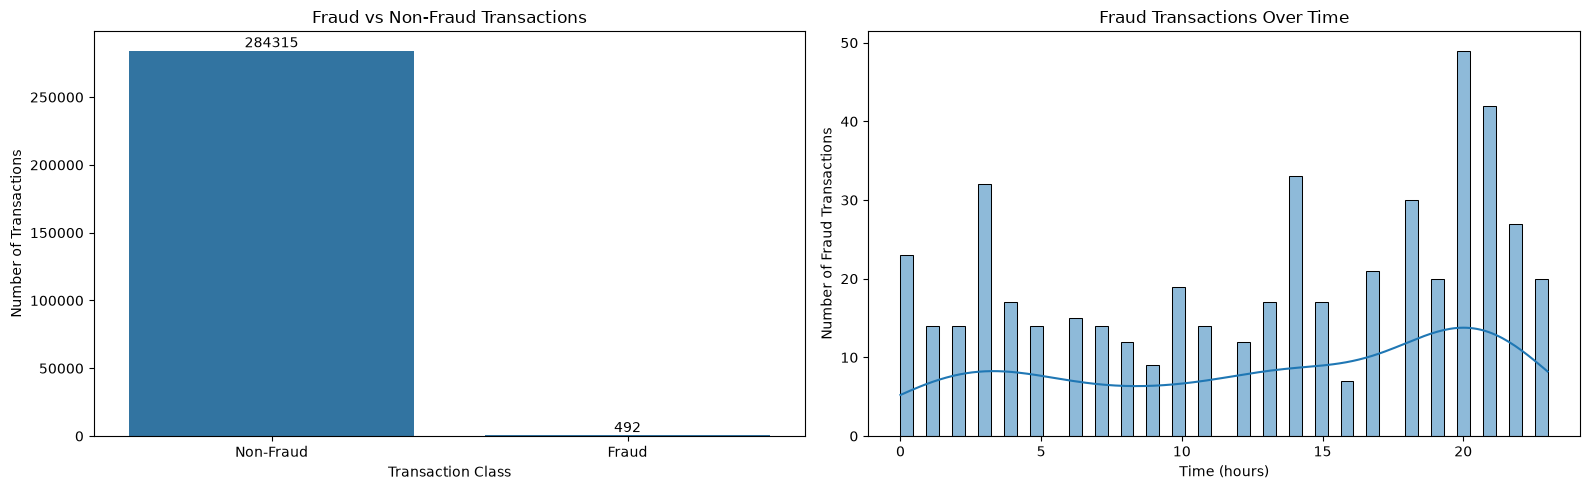

In [12]:
df["Hour"] = (df["Time"] // 360 % 24)
analyze_fraud(df)

findfont: Failed to find font weight black, now using 700.


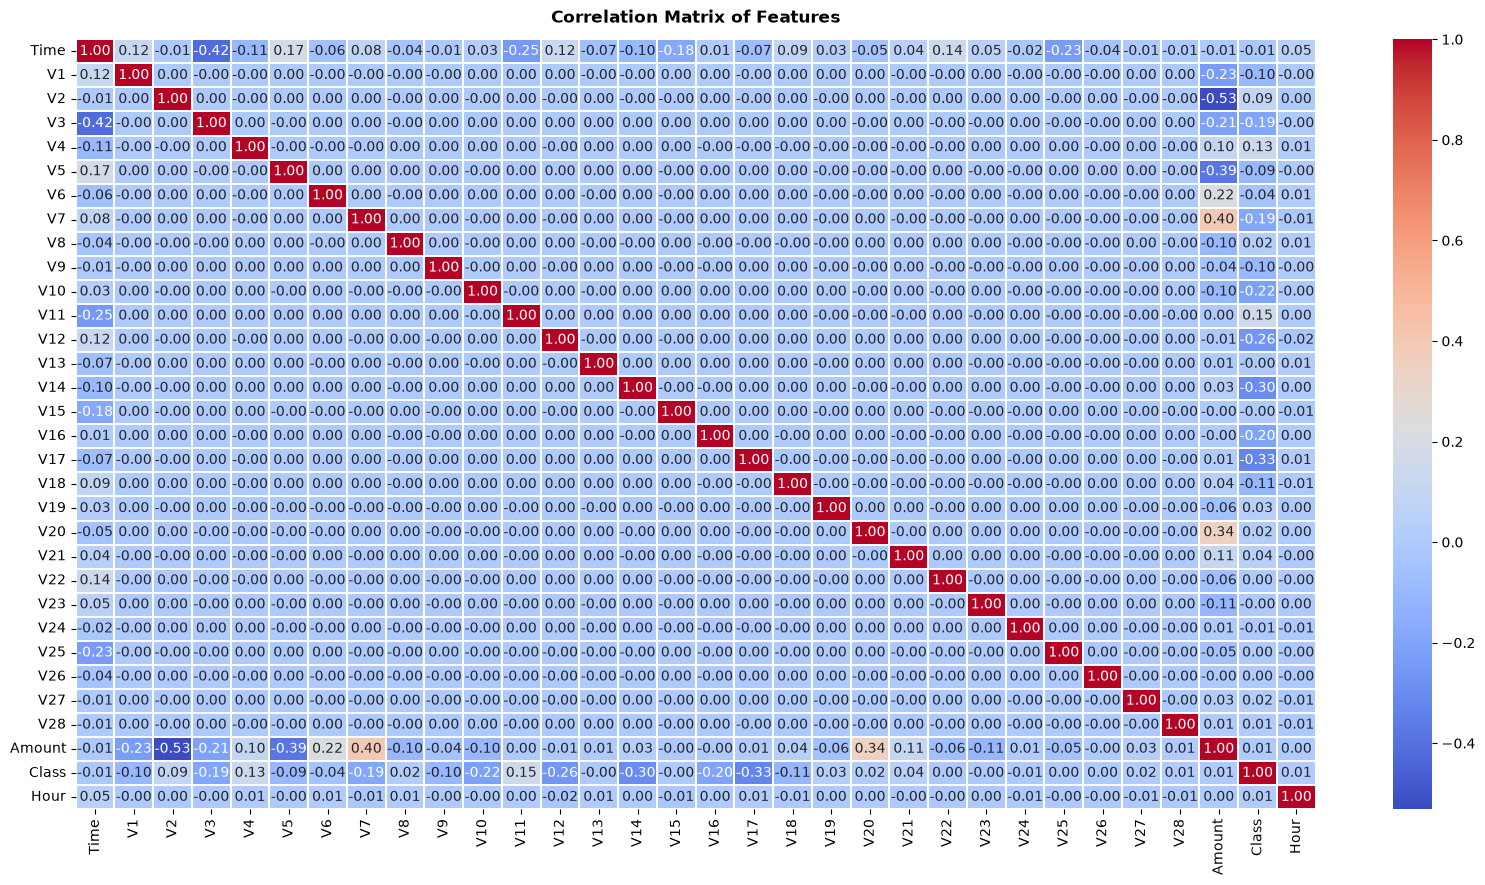

In [13]:
corr = df.corr()
plt.figure(figsize = (20, 10))
sns.heatmap(corr, annot=True, fmt='.2f', lw=0.2,cmap = 'coolwarm', annot_kws={'size': 10})
plt.title('Correlation Matrix of Features',fontweight = 'black', fontsize = 12, pad = 12)
plt.show()

# 3. Data preprocessing

In [14]:
df.drop(columns=["Time"],)

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,Hour
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,23.0
284803,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,23.0
284804,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,23.0
284805,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,23.0


In [15]:
X = df.drop(["Class", "Time"], axis=1)
y = df["Class"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42, stratify = y)

In [17]:
# =========================
# 1. V1 - V28
# =========================
v_cols = [f'V{i}' for i in range(1, 29)]

v_imputer = SimpleImputer(strategy='mean')
v_scaler = StandardScaler()

X_train[v_cols] = v_imputer.fit_transform(X_train[v_cols])
X_test[v_cols] = v_imputer.transform(X_test[v_cols])

X_train[v_cols] = v_scaler.fit_transform(X_train[v_cols])
X_test[v_cols] = v_scaler.transform(X_test[v_cols])



# =========================
# 2. Amount
# =========================
amount_imputer = SimpleImputer(strategy='median')
amount_scaler = StandardScaler()

# Fill missing values
X_train[['Amount']] = amount_imputer.fit_transform(X_train[['Amount']])
X_test[['Amount']] = amount_imputer.transform(X_test[['Amount']])

# Log transform
X_train['Amount'] = np.log1p(X_train['Amount'])
X_test['Amount'] = np.log1p(X_test['Amount'])

# Standardize
X_train[['Amount']] = amount_scaler.fit_transform(X_train[['Amount']])
X_test[['Amount']] = amount_scaler.transform(X_test[['Amount']])

In [18]:
print("Before SMOTE:")
print(Counter(y_train))

smote = SMOTE(
    sampling_strategy='auto',
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE:")
print(Counter(y_train_smote))

Before SMOTE:
Counter({0: 227451, 1: 394})
After SMOTE:
Counter({0: 227451, 1: 227451})


# 4. Model

In [19]:
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_log = log_model.predict(X_test)

# Probability of fraud
y_prob_log = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression")
print("===================")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))
print("PR-AUC:", average_precision_score(y_test, y_prob_log))

Logistic Regression
Confusion Matrix:
[[55276  1588]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.54     56962
weighted avg       1.00      0.97      0.98     56962

ROC-AUC: 0.9718529100582269
PR-AUC: 0.7203485905102561


In [20]:
def plot_confusion_matrix(y_test, y_pred, model_name):
    
    con_matrix = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        con_matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        linewidths=0.5,
        xticklabels=['Non-Fraud', 'Fraud'],
        yticklabels=['Non-Fraud', 'Fraud']
    )

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

    plt.show()

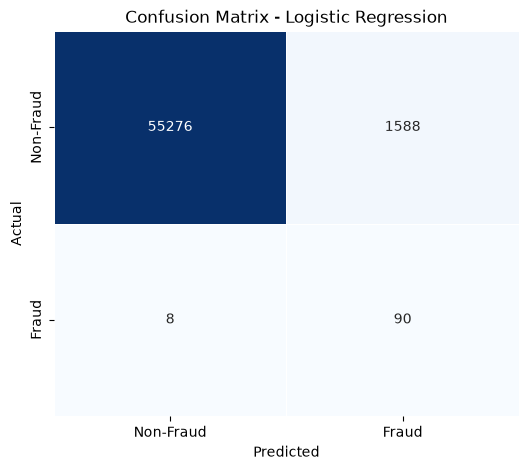

In [21]:
plot_confusion_matrix(
    y_test,
    y_pred_log,
    "Logistic Regression"
)

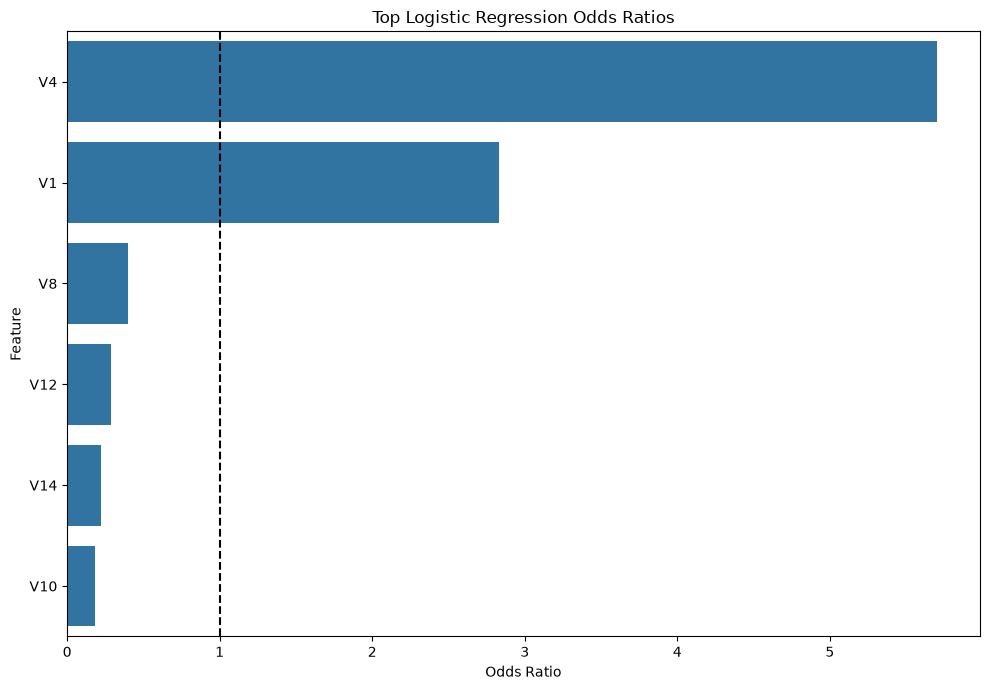

In [22]:
# Create Odds Ratio dataframe
or_df = pd.DataFrame({
    "Feature": X_train_smote.columns,
    "Coefficient": log_model.coef_[0]
})

or_df["Odds_Ratio"] = np.exp(or_df["Coefficient"])
or_df["Importance"] = or_df["Coefficient"].abs()

# Top 15 strongest effects
top_or = (
    or_df
    .sort_values("Importance", ascending=False)
    .head(6)
    .sort_values("Odds_Ratio", ascending=False)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_or,
    x="Odds_Ratio",
    y="Feature",
    order=top_or["Feature"]
)

plt.axvline(
    1,
    color="black",
    linestyle="--"
)

plt.title("Top Logistic Regression Odds Ratios")
plt.xlabel("Odds Ratio")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 2. Random forest

In [23]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Probability of fraud
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest")
print("=============")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

Random Forest
Confusion Matrix:
[[56852    12]
 [   18    80]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.87      0.82      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9617771331239305
PR-AUC: 0.8711069506654399


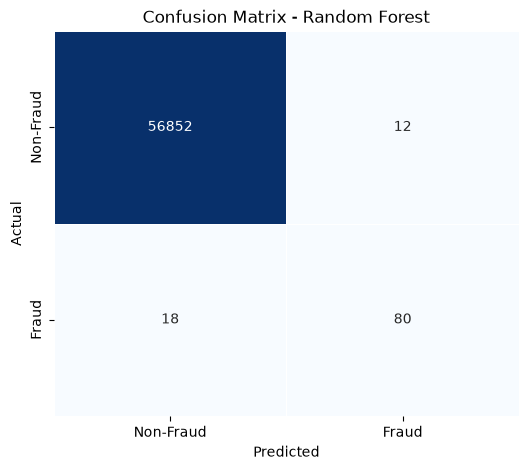

In [24]:
plot_confusion_matrix(
    y_test,
    y_pred_rf,
    "Random Forest"
)

# 5. Comparison

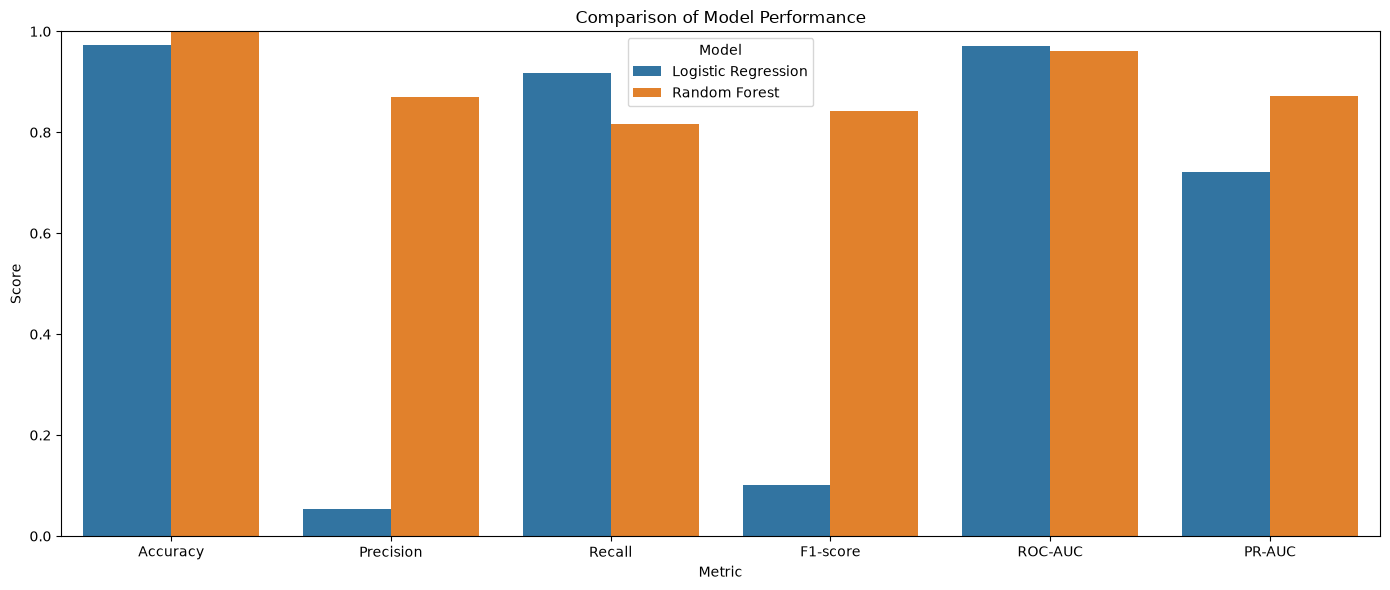

In [25]:
models = {
    "Logistic Regression": (y_test, y_pred_log, y_prob_log),
    "Random Forest": (y_test, y_pred_rf, y_prob_rf)
}

results = []

for name, (yt, yp, ypr) in models.items():

    report = classification_report(
        yt,
        yp,
        output_dict=True,
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(yt, yp),
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-score": report["1"]["f1-score"],
        "ROC-AUC": roc_auc_score(yt, ypr),
        "PR-AUC": average_precision_score(yt, ypr)
    })

df_results = pd.DataFrame(results)

# Convert to long format for seaborn
df_melted = df_results.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

# Bar chart
plt.figure(figsize=(14, 6))

sns.barplot(
    data=df_melted,
    x="Metric",
    y="Score",
    hue="Model"
)

plt.title("Comparison of Model Performance")
plt.xlabel("Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(title="Model")
plt.tight_layout()
plt.show()